In [1]:
"""
Python translation of http://sethares.engr.wisc.edu/comprog.html
"""
import numpy as np

In [2]:
def dissmeasure(fvec, amp, model='min'):
    """
    Given a list of partials in fvec, with amplitudes in amp, this routine
    calculates the dissonance by summing the roughness of every sine pair
    based on a model of Plomp-Levelt's roughness curve.

    The older model (model='product') was based on the product of the two
    amplitudes, but the newer model (model='min') is based on the minimum
    of the two amplitudes, since this matches the beat frequency amplitude.
    """
    # Sort by frequency
    sort_idx = np.argsort(fvec)
    am_sorted = np.asarray(amp)[sort_idx]
    fr_sorted = np.asarray(fvec)[sort_idx]

    # Used to stretch dissonance curve for different freqs:
    Dstar = 0.24  # Point of maximum dissonance
    S1 = 0.0207
    S2 = 18.96

    C1 = 5
    C2 = -5

    # Plomp-Levelt roughness curve:
    A1 = -3.51
    A2 = -5.75

    # Generate all combinations of frequency components
    idx = np.transpose(np.triu_indices(len(fr_sorted), 1))
    fr_pairs = fr_sorted[idx]
    am_pairs = am_sorted[idx]

    Fmin = fr_pairs[:, 0]
    S = Dstar / (S1 * Fmin + S2)
    Fdif = fr_pairs[:, 1] - fr_pairs[:, 0]

    if model == 'min':
        a = np.amin(am_pairs, axis=1)
    elif model == 'product':
        a = np.prod(am_pairs, axis=1)  # Older model
    else:
        raise ValueError('model should be "min" or "product"')
    SFdif = S * Fdif
    D = np.sum(a * (C1 * np.exp(A1 * SFdif) + C2 * np.exp(A2 * SFdif)))

    return D

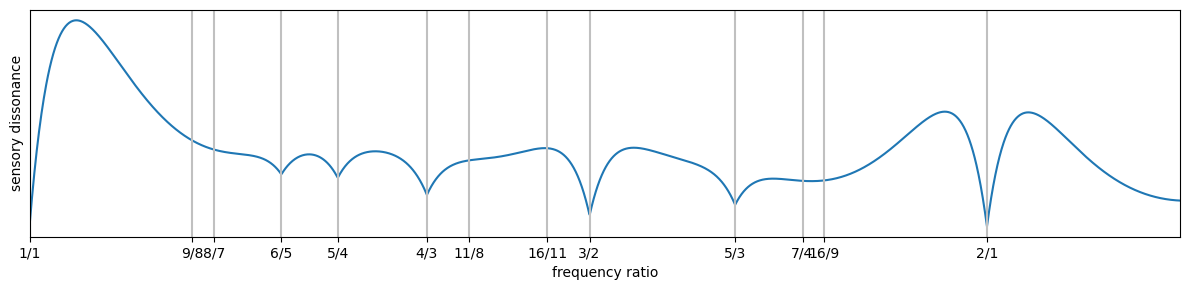

In [13]:
if __name__ == '__main__':
    from numpy import array, linspace, empty, concatenate
    import matplotlib.pyplot as plt

    """
    Reproduce Sethares Figure 3
    http://sethares.engr.wisc.edu/consemi.html#anchor15619672
    """
    freq = 500 * array([1, 2, 3, 4, 5, 6])
    amp = 0.88**array([0, 1, 2, 3, 4, 5])
    r_low = 1
    alpharange = 2.3
    method = 'product'

#    # Davide Verotta Figure 4 example
#    freq = 261.63 * array([1, 2, 3, 4, 5, 6])
#    amp = 1 / array([1, 2, 3, 4, 5, 6])
#    r_low = 1
#    alpharange = 2.0
#    method = 'product'

    n = 3000
    diss = empty(n)
    a = concatenate((amp, amp))
    for i, alpha in enumerate(linspace(r_low, alpharange, n)):
        f = concatenate((freq, alpha*freq))
        d = dissmeasure(f, a, method)
        diss[i] = d

    plt.figure(figsize=(12, 3))
    plt.plot(linspace(r_low, alpharange, len(diss)), diss)
    plt.xscale('log')
    plt.xlim(r_low, alpharange)

    plt.xlabel('frequency ratio')
    plt.ylabel('sensory dissonance')

    intervals = [(1, 1), (6, 5), (5, 4), (4, 3), (3, 2), (5, 3), (2, 1)]
    intervals = [(1, 1), (9, 8), (8,7), (6, 5), (5, 4), (4, 3), (11, 8), (16,11), (3, 2), (5, 3), (7,4), (16, 9), (2, 1)]
    
    for n, d in intervals:
        plt.axvline(n/d, color='silver')

    plt.yticks([])
    plt.minorticks_off()
    plt.xticks([n/d for n, d in intervals],
               ['{}/{}'.format(n, d) for n, d in intervals])
    plt.tight_layout()
    plt.show()